<a href="https://colab.research.google.com/github/athi-raj/Heart-Disease-Predictor/blob/main/Heart_Disease_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import & load

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

df = pd.read_csv('/content/drive/MyDrive/Heart-Disease-Predictor/heart_disease_uci.csv')

print("Dataset Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Data Cleaning & EDA

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


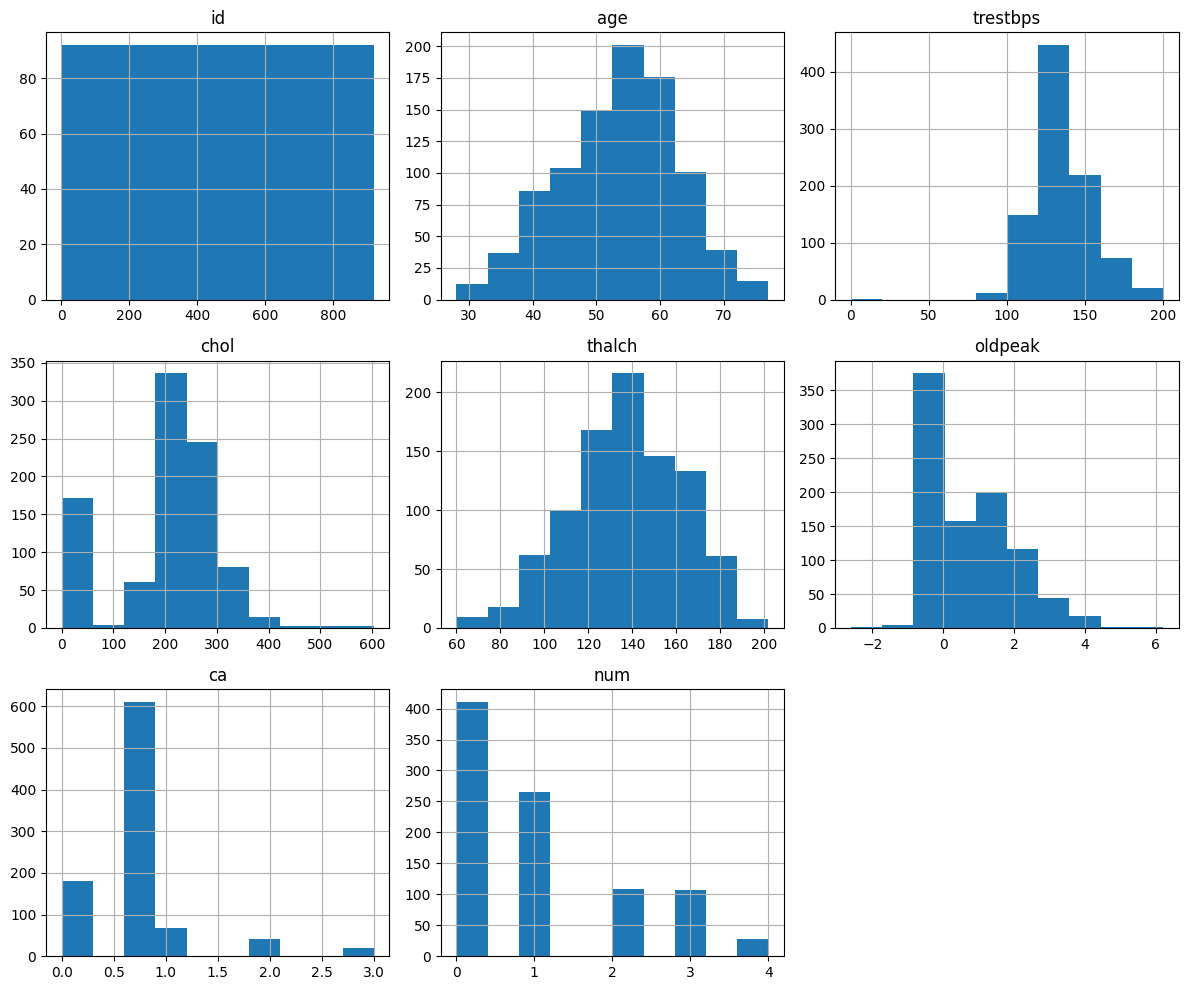

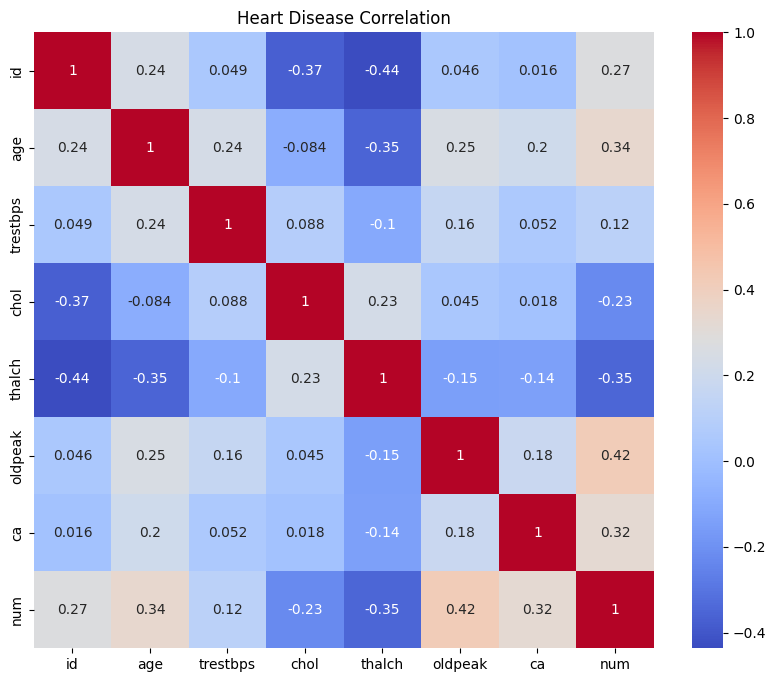

In [13]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

print(df.isnull().sum())

# Histogram
df[numeric_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Heart Disease Correlation")
plt.show()

Feature Engineering & Train-Test Split

In [3]:
y = (df['num'] > 0).astype(int)

X = df.drop('num', axis=1)

X = pd.get_dummies(X)

feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 736
Testing Records: 184


TensorFlow Model Training

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6446 - loss: 0.6249 - val_accuracy: 0.8446 - val_loss: 0.5364
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8248 - loss: 0.4004 - val_accuracy: 0.8446 - val_loss: 0.4799
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8554 - loss: 0.3413 - val_accuracy: 0.8716 - val_loss: 0.4472
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8741 - loss: 0.3187 - val_accuracy: 0.8649 - val_loss: 0.4279
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8844 - loss: 0.2787 - val_accuracy: 0.8784 - val_loss: 0.3998
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8980 - loss: 0.2613 - val_accuracy: 0.8649 - val_loss: 0.3909
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9065 - loss: 0.2450 - val_accuracy: 0.8716 - val_loss: 0.3670
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9167 - loss: 0.2320 - val_accuracy: 0.8649 - val_loss: 0.3539
Ep

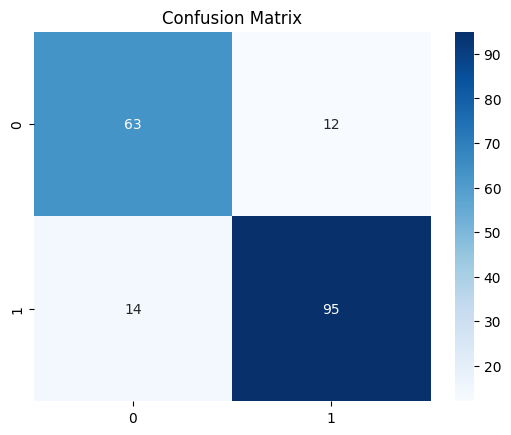

In [4]:
model = Sequential()

model.add(Dense(128, activation='relu',
                input_shape=(X_train_scaled.shape[1],)))

model.add(BatchNormalization())

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test_scaled, y_test)

print("Accuracy:", round(accuracy*100,2), "%")

y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Save Model & Single Patient Prediction

In [5]:
model.save('/content/drive/MyDrive/Heart-Disease-Predictor/heart_disease_model.keras')

joblib.dump(
    scaler,
    '/content/drive/MyDrive/Heart-Disease-Predictor/heart_scaler.pkl'
)

joblib.dump(
    feature_columns,
    '/content/drive/MyDrive/Heart-Disease-Predictor/heart_features.pkl'
)

print("Model Saved Successfully")

# Example Patient

sample = X.iloc[[0]].copy()

sample['age'] = 55
sample['trestbps'] = 140
sample['chol'] = 240
sample['thalch'] = 150
sample['oldpeak'] = 1.5

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("\nPrediction Result")

if prediction[0][0] > 0.5:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Model Saved Successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Prediction Result
No Heart Disease


In [7]:
# ==========================
# CONSOLE INPUT PREDICTION
# ==========================

print("\nEnter Patient Details")

age = int(input("Age: "))
sex = input("Sex (Male/Female): ")
dataset = input("Dataset (Cleveland/Hungary/Switzerland/VA): ")
cp = input("Chest Pain Type: ")
trestbps = float(input("Resting Blood Pressure: "))
chol = float(input("Cholesterol: "))
fbs = input("Fasting Blood Sugar (True/False): ")
restecg = input("Rest ECG: ")
thalch = float(input("Maximum Heart Rate: "))
exang = input("Exercise Angina (True/False): ")
oldpeak = float(input("Old Peak: "))
slope = input("Slope: ")
ca = float(input("Number of Major Vessels (ca): "))
thal = input("Thal: ")

# Create DataFrame
patient = pd.DataFrame({
    'id':[999],
    'age':[age],
    'sex':[sex],
    'dataset':[dataset],
    'cp':[cp],
    'trestbps':[trestbps],
    'chol':[chol],
    'fbs':[fbs],
    'restecg':[restecg],
    'thalch':[thalch],
    'exang':[exang],
    'oldpeak':[oldpeak],
    'slope':[slope],
    'ca':[ca],
    'thal':[thal]
})

# Apply same encoding as training
patient_encoded = pd.get_dummies(patient)

# Match training columns
patient_encoded = patient_encoded.reindex(
    columns=feature_columns,
    fill_value=0
)

# Scale
patient_scaled = scaler.transform(patient_encoded)

# Predict
prediction = model.predict(patient_scaled)

probability = prediction[0][0]

print("\n==============================")
print(" HEART DISEASE PREDICTION")
print("==============================")

if probability > 0.5:
    print("Result: Heart Disease Detected")
else:
    print("Result: No Heart Disease")

print(f"Confidence Score: {probability*100:.2f}%")
print("==============================")


Enter Patient Details
Age: 55
Sex (Male/Female): male
Dataset (Cleveland/Hungary/Switzerland/VA): cleveland
Chest Pain Type: typical angina
Resting Blood Pressure: 140
Cholesterol: 240
Fasting Blood Sugar (True/False): false
Rest ECG: normal
Maximum Heart Rate: 150
Exercise Angina (True/False): false
Old Peak: 1.5
Slope: flat
Number of Major Vessels (ca): 1
Thal: normal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

 HEART DISEASE PREDICTION
Result: Heart Disease Detected
Confidence Score: 97.95%


In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

# import pandas as pd
# import numpy as np
# import joblib
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Global Variables
# df = None
# model = None
# scaler = None
# feature_columns = None

# DATASET_PATH = "/content/drive/MyDrive/Heart-Disease-Predictor/heart_disease_uci.csv"

# # ==========================
# # LOAD DATA
# # ==========================
# def load_dataset():
#     global df

#     df = pd.read_csv(DATASET_PATH)

#     print("\nDataset Loaded Successfully")
#     print("Shape :", df.shape)
#     print("\nColumns:")
#     print(df.columns.tolist())

# # ==========================
# # EDA
# # ==========================
# def perform_eda():

#     if df is None:
#         print("Load Dataset First")
#         return

#     print("\nDataset Info")
#     print(df.info())

#     print("\nMissing Values")
#     print(df.isnull().sum())

#     numeric_cols = df.select_dtypes(include='number').columns

#     df[numeric_cols].hist(figsize=(12,10))
#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=(10,8))
#     sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
#     plt.title("Correlation Heatmap")
#     plt.show()

# # ==========================
# # TRAIN MODEL
# # ==========================
# def train_model():

#     global df, model, scaler, feature_columns

#     if df is None:
#         print("Load Dataset First")
#         return

#     data = df.copy()

#     # Fill Missing Numeric
#     numeric_cols = data.select_dtypes(include='number').columns
#     data[numeric_cols] = data[numeric_cols].fillna(
#         data[numeric_cols].mean()
#     )

#     # Fill Missing Categorical
#     cat_cols = data.select_dtypes(include='object').columns

#     for col in cat_cols:
#         data[col] = data[col].fillna("Unknown")

#     # Binary Target
#     y = (data["num"] > 0).astype(int)

#     X = data.drop("num", axis=1)

#     # One Hot Encoding
#     X = pd.get_dummies(X)

#     feature_columns = X.columns.tolist()

#     X_train, X_test, y_train, y_test = train_test_split(
#         X,
#         y,
#         test_size=0.2,
#         random_state=42
#     )

#     scaler = StandardScaler()

#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)

#     model = RandomForestClassifier(
#         n_estimators=100,
#         random_state=42
#     )

#     model.fit(X_train_scaled, y_train)

#     y_pred = model.predict(X_test_scaled)

#     print("\nAccuracy:",
#           round(accuracy_score(y_test,y_pred)*100,2),
#           "%")

#     print("\nClassification Report")
#     print(classification_report(y_test,y_pred))

#     cm = confusion_matrix(y_test,y_pred)

#     plt.figure(figsize=(5,4))
#     sns.heatmap(cm,
#                 annot=True,
#                 fmt='d',
#                 cmap='Blues')
#     plt.title("Confusion Matrix")
#     plt.show()

#     # Save Files
#     joblib.dump(model,
#                 "/content/drive/MyDrive/Heart-Disease-Predictor/heart_rf_model.pkl")

#     joblib.dump(scaler,
#                 "/content/drive/MyDrive/Heart-Disease-Predictor/heart_scaler.pkl")

#     joblib.dump(feature_columns,
#                 "/content/drive/MyDrive/Heart-Disease-Predictor/heart_features.pkl")

#     print("\nModel Saved Successfully")

# # ==========================
# # SINGLE PREDICTION
# # ==========================
# def predict_heart():

#     model = joblib.load(
#         "/content/drive/MyDrive/Heart-Disease-Predictor/heart_rf_model.pkl"
#     )

#     scaler = joblib.load(
#         "/content/drive/MyDrive/Heart-Disease-Predictor/heart_scaler.pkl"
#     )

#     feature_columns = joblib.load(
#         "/content/drive/MyDrive/Heart-Disease-Predictor/heart_features.pkl"
#     )

#     print("\nEnter Patient Details")

#     age = int(input("Age : "))
#     sex = input("Sex (Male/Female) : ")
#     dataset = input("Dataset (Cleveland) : ")
#     cp = input("Chest Pain Type : ")
#     trestbps = float(input("Blood Pressure : "))
#     chol = float(input("Cholesterol : "))
#     fbs = input("Fasting Blood Sugar (True/False) : ")
#     restecg = input("Rest ECG : ")
#     thalch = float(input("Max Heart Rate : "))
#     exang = input("Exercise Angina (True/False) : ")
#     oldpeak = float(input("Old Peak : "))
#     slope = input("Slope : ")
#     ca = float(input("CA : "))
#     thal = input("Thal : ")

#     patient = pd.DataFrame({
#         "id":[999],
#         "age":[age],
#         "sex":[sex],
#         "dataset":[dataset],
#         "cp":[cp],
#         "trestbps":[trestbps],
#         "chol":[chol],
#         "fbs":[fbs],
#         "restecg":[restecg],
#         "thalch":[thalch],
#         "exang":[exang],
#         "oldpeak":[oldpeak],
#         "slope":[slope],
#         "ca":[ca],
#         "thal":[thal]
#     })

#     patient = pd.get_dummies(patient)

#     patient = patient.reindex(
#         columns=feature_columns,
#         fill_value=0
#     )

#     patient_scaled = scaler.transform(patient)

#     prediction = model.predict(patient_scaled)

#     probability = model.predict_proba(patient_scaled)

#     print("\n====================")

#     if prediction[0] == 1:
#         print("Heart Disease Detected")
#     else:
#         print("No Heart Disease")

#     print("Confidence:",
#           round(max(probability[0])*100,2),
#           "%")

#     print("====================")

# # ==========================
# # MENU
# # ==========================
# while True:

#     print("\n================================")
#     print(" HEART DISEASE PREDICTION ")
#     print("================================")

#     print("1. Load Dataset")
#     print("2. EDA")
#     print("3. Train Model")
#     print("4. Predict")
#     print("5. Exit")

#     choice = input("Enter Choice : ")

#     if choice == "1":
#         load_dataset()

#     elif choice == "2":
#         perform_eda()

#     elif choice == "3":
#         train_model()

#     elif choice == "4":
#         predict_heart()

#     elif choice == "5":
#         print("Thank You")
#         break

#     else:
#         print("Invalid Choice")